# RODADA 2 — Mapa de favorabilidade (Au) com Random Forest

Fluxo: rasters → grade única (recorte pela área) → pontos positivos → negativos
amostrados só em pixels válidos → **validação cruzada espacial** (repetida em
vários sorteios de negativos) → teste de vazamento → modelo final → mapa → exportação.

Estrutura esperada no Google Drive (ajuste na célula de configuração):
```
RODADA2/
├── rasters/   (13 GeoTIFFs)
├── pontos/    Pontos_treinamento_positivos.shp (+ .dbf .shx .prj)
├── area/      area_projeto.shp (+ .dbf .shx .prj)
└── saidas/    (criada automaticamente)
```

In [ ]:
# Instalação (no Colab rasterio/geopandas normalmente já vêm instalados)
%pip install -q rasterio geopandas shapely scikit-learn seaborn

In [ ]:
# Imports e montagem do Drive
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns
from rasterio.enums import Resampling
from rasterio.features import geometry_mask
from rasterio.transform import from_origin, rowcol
from rasterio.warp import calculate_default_transform, reproject
from scipy.ndimage import gaussian_filter
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (average_precision_score, confusion_matrix,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict

try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:      # rodando fora do Colab
    pass

Mounted at /content/drive


In [ ]:
# =========================== CONFIGURAÇÃO ===========================
SEED = 42
TARGET_CRS = "EPSG:32721"                      # WGS 84 / UTM 21S

BASE_DIR    = "/content/drive/MyDrive/RODADA2"
RASTER_DIR  = f"{BASE_DIR}/rasters"
PONTOS_PATH = f"{BASE_DIR}/pontos/Pontos_treinamento_positivos.shp"   # .shp ou .csv (colunas X, Y)
AREA_PATH   = f"{BASE_DIR}/area/area_projeto.shp"
OUT_DIR     = f"{BASE_DIR}/saidas"
PONTOS_CRS_CSV = TARGET_CRS                    # só usado se os pontos forem CSV

RASTER_FILES = [
    "geofisica_ASA.tif", "geofisica_gama_eTh.tif", "geofisica_gama_eU.tif",
    "geofisica_gama_Ffactor.tif", "geofisica_gama_kperc.tif",
    "geofisica_gama_ternario.tif", "geofisica_gama_UThrazao.tif",
    "geoquim_disttotopAu.tif", "geoquim_kde.tif",
    "indice_BRBA.tif", "indice_Clay.tif", "indice_Hydrothermal.tif", "indice_NDVI.tif",
]

# Rasters retirados do modelo. O ternário costuma ser RGB (3 bandas) e é redundante
# com eTh/eU/K. Se quiser testar sem as camadas geoquímicas (risco de vazamento),
# acrescente "geoquim_kde" e "geoquim_disttotopAu" aqui.
RASTERS_EXCLUIDOS = ["geofisica_gama_ternario"]

RESOLUCAO_M = None                 # None = usa a resolução do 1º raster
RESAMPLING_PADRAO = "bilinear"     # dados contínuos
RESAMPLING_POR_RASTER = {}         # ex.: {"indice_Clay": "nearest"} para dados categóricos

BUFFER_POS_M   = 100               # negativos ficam a mais de 100 m dos positivos
MIN_DIST_NEG_M = 50                # distância mínima entre negativos
NEG_RATIO      = 1.0               # negativos por positivo
N_REPEATS      = 5                 # sorteios de negativos usados na validação
BLOCK_SIZE_M   = 2000              # tamanho do bloco da validação espacial
N_SPLITS       = 5
SMOOTH_SIGMA   = 3                 # em pixels; 0 = sem suavização
NODATA_OUT     = -9999.0

Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

## 1. Grade de referência e empilhamento dos rasters
Cada raster é reprojetado **uma única vez**, direto do original para a grade final
(evita a dupla reamostragem da versão anterior). Fora da área do projeto o valor é NaN.

In [ ]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import from_origin
from rasterio.features import geometry_mask
from pathlib import Path
import warnings

# Verificação de existência
faltando = [f for f in RASTER_FILES if not (Path(RASTER_DIR) / f).exists()]
if faltando:
    raise FileNotFoundError(f"Rasters não encontrados em {RASTER_DIR}: {faltando}")

area = gpd.read_file(AREA_PATH)
if area.crs is None:
    raise ValueError("O shapefile da área não tem CRS (.prj ausente).")
area = area.to_crs(TARGET_CRS)

files_used = [f for f in RASTER_FILES if Path(f).stem not in RASTERS_EXCLUIDOS]

# Mapeia todas as bandas de cada arquivo para gerar a lista de features
feature_info = []  # Lista de tuplas: (nome_arquivo, indice_banda, nome_feature)
for fname in files_used:
    stem = Path(fname).stem
    with rasterio.open(Path(RASTER_DIR) / fname) as src:
        if src.crs is None:
            raise ValueError(f"{fname} não tem CRS.")
        for b in range(1, src.count + 1):
            feat_name = f"{stem}_b{b}" if src.count > 1 else stem
            feature_info.append((fname, b, feat_name))

FEATURE_NAMES = [info[2] for info in feature_info]

# Resolução
if RESOLUCAO_M is None:
    with rasterio.open(Path(RASTER_DIR) / files_used[0]) as s:
        t, _, _ = calculate_default_transform(s.crs, TARGET_CRS, s.width, s.height, *s.bounds)
        RES = abs(t.a)
else:
    RES = float(RESOLUCAO_M)

# Grade cobrindo a área do projeto
xmin, ymin, xmax, ymax = area.total_bounds
xmin, ymax = np.floor(xmin / RES) * RES, np.ceil(ymax / RES) * RES
W = int(np.ceil((xmax - xmin) / RES))
H = int(np.ceil((ymax - ymin) / RES))
GRID_TRANSFORM = from_origin(xmin, ymax, RES, RES)
print(f"Grade: {H} x {W} pixels | resolução {RES:.2f} m | {len(FEATURE_NAMES)} camadas/bandas no total")

inside = geometry_mask(area.geometry, out_shape=(H, W), transform=GRID_TRANSFORM, invert=True)

# Stack alocado considerando o total de BANDAS acumuladas
stack = np.full((H, W, len(FEATURE_NAMES)), np.nan, dtype="float32")

for k, (fname, band_idx, feat_name) in enumerate(feature_info):
    stem = Path(fname).stem
    with rasterio.open(Path(RASTER_DIR) / fname) as src:
        method = getattr(Resampling, RESAMPLING_POR_RASTER.get(stem, RESAMPLING_PADRAO))
        layer = np.full((H, W), np.nan, dtype="float32")

        reproject(
            source=rasterio.band(src, band_idx),
            destination=layer,
            src_nodata=src.nodata,
            dst_transform=GRID_TRANSFORM,
            dst_crs=TARGET_CRS,
            dst_nodata=np.nan,
            resampling=method,
        )

    layer[~np.isfinite(layer) | (np.abs(layer) > 1e30)] = np.nan   # nodata "vazado"
    layer[~inside] = np.nan
    stack[:, :, k] = layer
    print(f"  {feat_name:<32s} válido na área: {np.isfinite(layer[inside]).mean():6.1%}")
    del layer

valid = inside & np.isfinite(stack).all(axis=-1)
print(f"\nPixels válidos em TODAS as bandas: {valid.sum():,} ({valid.sum() / inside.sum():.1%} da área)")
if valid.sum() / inside.sum() < 0.9:
    warnings.warn("Menos de 90% da área tem dado em todas as bandas — confira a cobertura.")

## 2. Pontos positivos
Explode MultiPoint, reprojeta, remove geometrias nulas, coordenadas duplicadas
(mantém a de maior Au) e pontos fora da área ou sobre pixels sem dado.

In [ ]:
if PONTOS_PATH.lower().endswith(".csv"):
    df = pd.read_csv(PONTOS_PATH)
    pts = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["X"], df["Y"]), crs=PONTOS_CRS_CSV)
else:
    pts = gpd.read_file(PONTOS_PATH)

if pts.crs is None:
    warnings.warn(f"Pontos sem CRS; assumindo {TARGET_CRS}.")
    pts = pts.set_crs(TARGET_CRS)
else:
    pts = pts.to_crs(TARGET_CRS)

n0 = len(pts)
pts = pts[pts.geometry.notna() & ~pts.geometry.is_empty]
pts = pts.explode(index_parts=False).reset_index(drop=True)
pts = pts[pts.geom_type == "Point"].copy()
pts["x"], pts["y"] = pts.geometry.x, pts.geometry.y
if "Au" in pts.columns:
    pts = pts.sort_values("Au", ascending=False, na_position="last")
pts = (pts.assign(_xr=pts.x.round(1), _yr=pts.y.round(1))
          .drop_duplicates(["_xr", "_yr"]).drop(columns=["_xr", "_yr"])
          .reset_index(drop=True))
n_dedup = len(pts)


def sample_stack(xs, ys):
    """Valores do stack nas coordenadas (NaN se fora da grade)."""
    r, c = rowcol(GRID_TRANSFORM, np.asarray(xs), np.asarray(ys))
    r, c = np.asarray(r), np.asarray(c)
    ok = (r >= 0) & (r < H) & (c >= 0) & (c < W)
    X = np.full((len(r), stack.shape[-1]), np.nan, dtype="float32")
    X[ok] = stack[r[ok], c[ok]]
    return X


X_pos = sample_stack(pts.x, pts.y)
keep = np.isfinite(X_pos).all(axis=1)
print(f"Pontos lidos: {n0} | após explode/duplicatas: {n_dedup} | "
      f"válidos (dentro da área e com dado): {keep.sum()}")
pts = pts[keep].reset_index(drop=True)
X_pos = X_pos[keep]
xy_pos = pts[["x", "y"]].to_numpy()
N_POS = len(pts)
if N_POS < 20:
    warnings.warn("Poucos positivos válidos; as métricas serão muito instáveis.")

Pontos lidos: 40 | após explode/duplicatas: 26 | válidos (dentro da área e com dado): 26


## 3. Negativos (pseudo-ausências)
Sorteados **só em pixels válidos**, fora do buffer dos positivos, com distância mínima
entre si e `seed` fixa. Como "sem amostra" ≠ "sem ouro", a validação é repetida em
`N_REPEATS` sorteios diferentes e reportada como média ± desvio.

In [ ]:
near_pos = geometry_mask(pts.geometry.buffer(BUFFER_POS_M), out_shape=(H, W),
                         transform=GRID_TRANSFORM, invert=True)
cand_idx_all = np.flatnonzero((valid & ~near_pos).ravel())
print(f"Pixels candidatos a negativo: {len(cand_idx_all):,}")
N_NEG = int(round(N_POS * NEG_RATIO))


def draw_negatives(n, seed):
    rng = np.random.default_rng(seed)
    cand = rng.choice(cand_idx_all, size=min(len(cand_idx_all), n * 100), replace=False)
    sel = []
    xy = np.empty((0, 2))
    for idx in cand:
        r, c = divmod(int(idx), W)
        x, y = GRID_TRANSFORM * (c + 0.5, r + 0.5)
        if len(xy) and np.min(np.hypot(xy[:, 0] - x, xy[:, 1] - y)) < MIN_DIST_NEG_M:
            continue
        sel.append((r, c))
        xy = np.vstack([xy, [x, y]])
        if len(sel) == n:
            break
    if len(sel) < n:
        warnings.warn(f"Só foi possível sortear {len(sel)} de {n} negativos.")
    rr, cc = np.array(sel).T
    return {"seed": seed, "X": stack[rr, cc], "xy": xy}


draws = [draw_negatives(N_NEG, SEED + i) for i in range(N_REPEATS)]
print(f"{N_REPEATS} sorteios de {N_NEG} negativos | {N_POS} positivos")

Pixels candidatos a negativo: 7,979,771
5 sorteios de 26 negativos | 26 positivos


## 4. Validação cruzada espacial
Blocos de `BLOCK_SIZE_M` metros ficam inteiros no treino ou no teste
(`StratifiedGroupKFold`), evitando o otimismo do CV aleatório com pontos vizinhos.
Métricas: AUC-ROC e AUC-PR (independem de limiar) + recall/precisão em 0,5.

In [ ]:
def make_rf(seed=SEED):
    return RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample",
                                  random_state=seed, n_jobs=-1)


def block_groups(xy):
    bx = np.floor(xy[:, 0] / BLOCK_SIZE_M).astype(np.int64)
    by = np.floor(xy[:, 1] / BLOCK_SIZE_M).astype(np.int64)
    return bx * 1_000_000 + by


def build_xy(d, cols):
    X = np.vstack([X_pos, d["X"]])[:, cols]
    y = np.r_[np.ones(len(X_pos)), np.zeros(len(d["X"]))]
    groups = block_groups(np.vstack([xy_pos, d["xy"]]))
    return X, y, groups


def run_cv(cols, keep_first=False):
    rows, first = [], None
    for d in draws:
        X, y, g = build_xy(d, cols)
        cv = StratifiedGroupKFold(N_SPLITS, shuffle=True, random_state=d["seed"])
        proba = cross_val_predict(make_rf(d["seed"]), X, y, cv=cv, groups=g,
                                  method="predict_proba")[:, 1]
        pred = proba >= 0.5
        rows.append({"AUC-ROC": roc_auc_score(y, proba),
                     "AUC-PR": average_precision_score(y, proba),
                     "Recall": recall_score(y, pred),
                     "Precisão": precision_score(y, pred, zero_division=0)})
        if first is None:
            first = (X, y, g, proba, cv)
    return pd.DataFrame(rows), first


ALL = list(range(len(FEATURE_NAMES)))
NO_GEOQUIM = [i for i, n in enumerate(FEATURE_NAMES) if not n.startswith("geoquim")]

cv_all, first = run_cv(ALL)
resumo = {"todas as camadas": cv_all.agg(["mean", "std"]).T}
print("=== CV espacial — todas as camadas ===")
print(cv_all.agg(["mean", "std"]).T.round(3))

# Teste de vazamento: as camadas geoquímicas (KDE / distância ao Au) foram calculadas
if 0 < len(NO_GEOQUIM) < len(ALL):
    cv_nog, _ = run_cv(NO_GEOQUIM)
    resumo["sem camadas geoquim_*"] = cv_nog.agg(["mean", "std"]).T
    print("\n=== CV espacial — SEM camadas geoquim_* (teste de vazamento) ===")
    print(cv_nog.agg(["mean", "std"]).T.round(3))
    delta = cv_all["AUC-ROC"].mean() - cv_nog["AUC-ROC"].mean()
    if delta > 0.05:
        print(f"\n⚠ AUC-ROC cai {delta:.3f} sem as camadas geoquímicas. Confirme que KDE e "
              "distância ao Au NÃO usam as amostras de treino/teste.")

pd.concat(resumo, names=["modelo", "métrica"]).round(4).to_csv(f"{OUT_DIR}/metricas_cv_espacial.csv")

=== CV espacial — todas as camadas ===
           mean    std
AUC-ROC   0.843  0.103
AUC-PR    0.818  0.108
Recall    0.777  0.113
Precisão  0.825  0.085

=== CV espacial — SEM camadas geoquim_* (teste de vazamento) ===
           mean    std
AUC-ROC   0.654  0.055
AUC-PR    0.616  0.063
Recall    0.431  0.132
Precisão  0.604  0.033

⚠ AUC-ROC cai 0.189 sem as camadas geoquímicas.

## 5. Matriz de confusão e importância das variáveis
Matriz: predições *out-of-fold* do 1º sorteio (limiar 0,5).
Importância por permutação: calculada nos blocos de **teste**. 

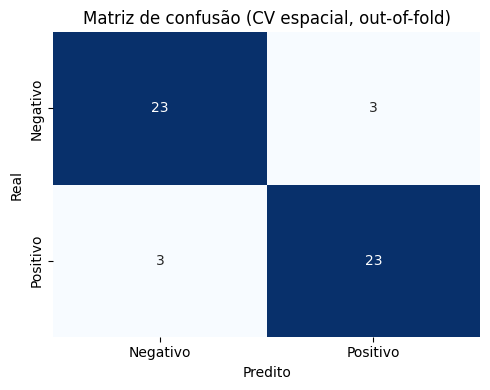

In [ ]:
X1, y1, g1, proba1, cv1 = first
cm = confusion_matrix(y1, proba1 >= 0.5)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Negativo", "Positivo"], yticklabels=["Negativo", "Positivo"])
plt.title("Matriz de confusão (CV espacial, out-of-fold)")
plt.xlabel("Predito"); plt.ylabel("Real")
plt.tight_layout(); plt.show()

perm = np.zeros(len(FEATURE_NAMES)); n_ok = 0
for tr, te in cv1.split(X1, y1, g1):
    if len(np.unique(y1[te])) < 2:
        continue
    m = make_rf().fit(X1[tr], y1[tr])
    r = permutation_importance(m, X1[te], y1[te], scoring="roc_auc",
                               n_repeats=20, random_state=SEED, n_jobs=-1)
    perm += r.importances_mean; n_ok += 1
perm /= max(n_ok, 1)

## 6. Modelo final e mapa de favorabilidade
O valor do mapa é um **índice relativo de favorabilidade (0–1)**, não uma probabilidade
real de ocorrência (as classes foram balanceadas artificialmente).

In [ ]:
final_draw = draw_negatives(N_NEG, SEED + 999)
X_fin = np.vstack([X_pos, final_draw["X"]])
y_fin = np.r_[np.ones(len(X_pos)), np.zeros(len(final_draw["X"]))]
rf_final = make_rf().fit(X_fin, y_fin)

imp = pd.DataFrame({"raster": FEATURE_NAMES,
                    "importancia_impureza": rf_final.feature_importances_,
                    "importancia_permutacao_teste": perm}
                   ).sort_values("importancia_permutacao_teste", ascending=False)
print(imp.round(4).to_string(index=False))
imp.to_csv(f"{OUT_DIR}/importancia_rasters.csv", index=False)

# predição só nos pixels válidos, em blocos (evita estourar a memória)
flat = stack.reshape(-1, stack.shape[-1])
idx = np.flatnonzero(valid.ravel())
out = np.empty(len(idx), dtype="float32")
for i in range(0, len(idx), 500_000):
    out[i:i + 500_000] = rf_final.predict_proba(flat[idx[i:i + 500_000]])[:, 1]
fav = np.full((H, W), np.nan, dtype="float32")
fav.flat[idx] = out

# suavização gaussiana que respeita a máscara (NaN não "vaza" para dentro da área)
if SMOOTH_SIGMA and SMOOTH_SIGMA > 0:
    num = gaussian_filter(np.where(valid, fav, 0.0), SMOOTH_SIGMA)
    den = gaussian_filter(valid.astype("float32"), SMOOTH_SIGMA)
    fav_smooth = np.where(valid & (den > 1e-6), num / np.maximum(den, 1e-6), np.nan).astype("float32")
else:
    fav_smooth = fav.copy()

                 raster  importancia_impureza  importancia_permutacao_teste
            geoquim_kde                0.2944                        0.1128
            indice_BRBA                0.1551                        0.0123
            indice_NDVI                0.0770                        0.0083
geofisica_gama_UThrazao                0.0221                        0.0056
            indice_Clay                0.0674                        0.0041
   geofisica_gama_kperc                0.0250                        0.0020
 geofisica_gama_Ffactor                0.0254                        0.0006
     geofisica_gama_eTh                0.0121                       -0.0013
      geofisica_gama_eU                0.0155                       -0.0089
          geofisica_ASA                0.0310                       -0.0104
    geoquim_disttotopAu                0.2086                       -0.0142
    indice_Hydrothermal                0.0665                       -0.0224


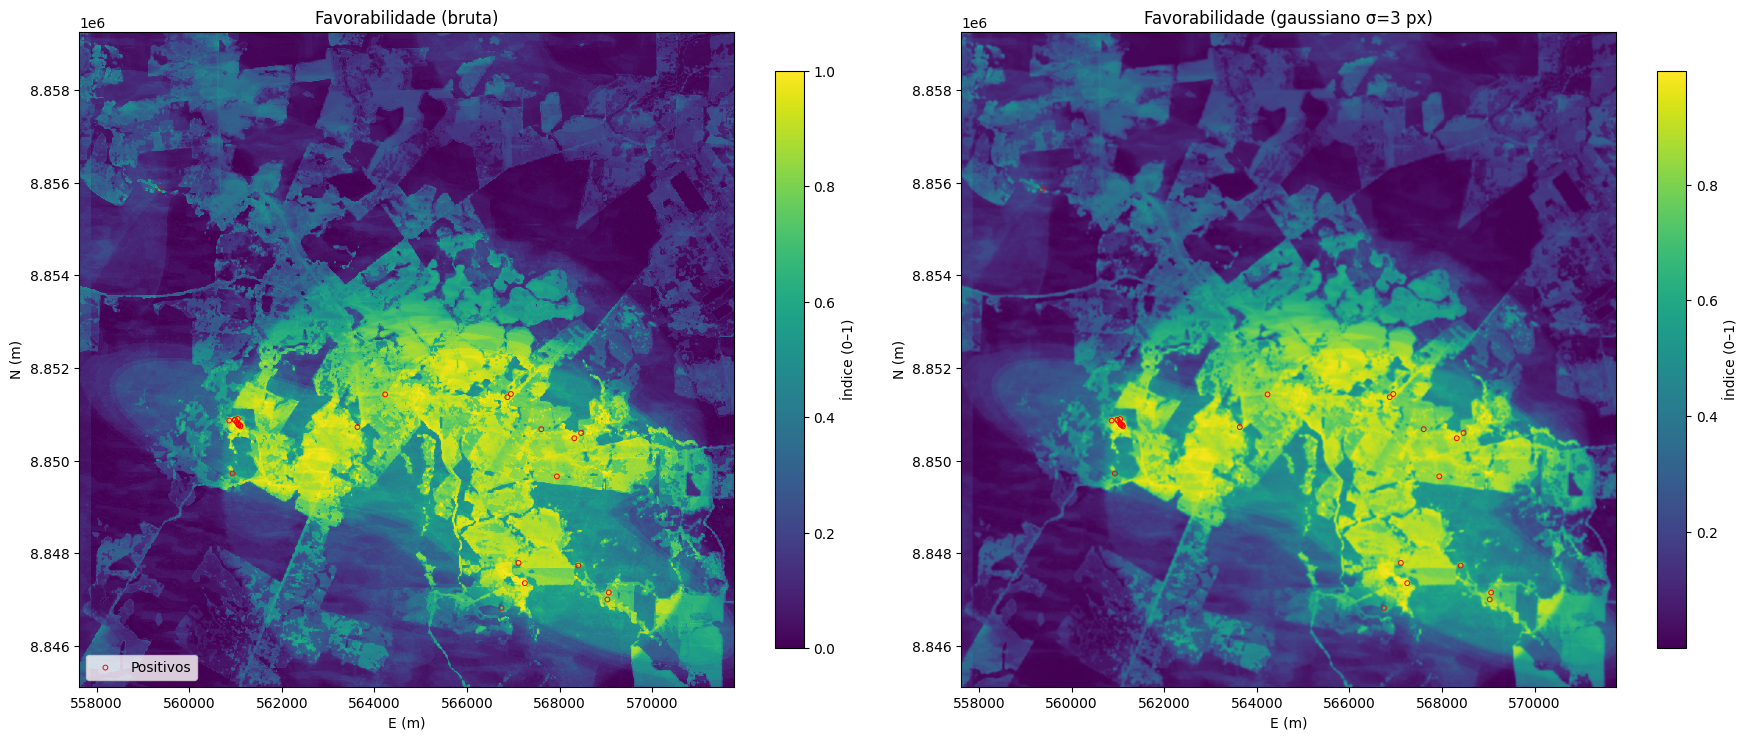

In [ ]:
# Mapas
extent = (GRID_TRANSFORM.c, GRID_TRANSFORM.c + W * RES, GRID_TRANSFORM.f - H * RES, GRID_TRANSFORM.f)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, arr, title in zip(axes, [fav, fav_smooth],
                          ["Favorabilidade (bruta)", f"Favorabilidade (gaussiano σ={SMOOTH_SIGMA} px)"]):
    im = ax.imshow(arr, cmap="viridis", extent=extent, interpolation="nearest")
    ax.scatter(pts.x, pts.y, s=12, facecolors="none", edgecolors="red", linewidths=0.7, label="Positivos")
    ax.set_title(title); ax.set_xlabel("E (m)"); ax.set_ylabel("N (m)")
    plt.colorbar(im, ax=ax, shrink=0.75, label="Índice (0–1)")
axes[0].legend(loc="lower left")
plt.tight_layout(); plt.show()

## 7. Exportação (salva no Drive, pasta `saidas/`)

In [ ]:
profile = dict(driver="GTiff", height=H, width=W, crs=TARGET_CRS,
               transform=GRID_TRANSFORM, compress="deflate")


def save_float(arr, path):
    with rasterio.open(path, "w", count=1, dtype="float32", nodata=NODATA_OUT, **profile) as dst:
        dst.write(np.where(np.isfinite(arr), arr, NODATA_OUT).astype("float32"), 1)


save_float(fav, f"{OUT_DIR}/favorability_raw.tif")
save_float(fav_smooth, f"{OUT_DIR}/favorability_smooth.tif")

# TIFF colorido (RGBA) apenas para visualização — NaN fica transparente
lo, hi = np.nanmin(fav_smooth), np.nanmax(fav_smooth)
rgba = (plt.get_cmap("viridis")((fav_smooth - lo) / (hi - lo)) * 255).astype("uint8")
rgba[~np.isfinite(fav_smooth), 3] = 0
with rasterio.open(f"{OUT_DIR}/favorability_heatmap_rgba.tif", "w", count=4, dtype="uint8",
                   photometric="RGB", alpha="yes", **profile) as dst:
    dst.write(np.moveaxis(rgba, -1, 0))

# tabela de treino (útil para auditar / reproduzir)
tab = pd.DataFrame(np.vstack([X_pos, X_fin[len(X_pos):]]), columns=FEATURE_NAMES)
tab.insert(0, "classe", y_fin.astype(int))
tab.to_csv(f"{OUT_DIR}/tabela_treino.csv", index=False)

print("Arquivos salvos em:", OUT_DIR)
for p in sorted(Path(OUT_DIR).glob("*")):
    print("  ", p.name)

# from google.colab import files; files.download(f"{OUT_DIR}/favorability_smooth.tif")

Arquivos salvos em: /content/drive/MyDrive/RODADA2/saidas
   favorability_heatmap_rgba.tif
   favorability_raw.tif
   favorability_smooth.tif
   importancia_rasters.csv
   metricas_cv_espacial.csv
   tabela_treino.csv
